In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
!pip install flaml
from flaml import AutoML
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 4.8 MB/s eta 0:00:00


In [4]:
df=pd.read_csv('final_HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,OverTime,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,2,2,3,4,5993,8,1,...,0,0,0,0,0,0,1,0,0,1
1,49,0,8,1,3,2,2,5130,1,0,...,0,0,0,0,0,1,0,0,1,0
2,37,1,2,2,4,2,3,2090,6,1,...,0,1,0,0,0,0,0,0,0,1
3,33,0,3,4,4,3,3,2909,1,1,...,0,0,0,0,0,1,0,0,1,0
4,27,0,2,1,1,3,2,3468,9,0,...,0,1,0,0,0,0,0,0,1,0


## 切分資料集

In [5]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

### 切訓練與測試集

In [6]:
# 設定要測試的拆分比例
split_ratios = [i/10 for i in range(1, 10)]
train_f1_scores = []
test_f1_scores = []

automl = AutoML()
settings = {
    "time_budget": 60,  # total running time in seconds
    "metric": "f1",
    "estimator_list": [
        "xgboost"
    ],  # list of ML learners; we tune XGBoost in this example
    "task": "classification",  # task type
    "log_file_name": "xgboost_experiment.log",  # flaml log file
    "seed": 42,  # random seed
    "verbose": 0,
}

print("開始測試不同切分比例...")
for sr in split_ratios:
    # 確保資料不平衡時使用 stratify
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=sr, random_state=42, stratify=y)

    automl.fit(X_train=X_train, y_train=y_train, **settings)

    # 分別預測訓練集與測試集
    train_preds = automl.predict(X_train)
    test_preds = automl.predict(X_test)

    # 計算 F1 Score 並記錄
    train_score = f1_score(y_train, train_preds)
    test_score = f1_score(y_test, test_preds)

    train_f1_scores.append(train_score)
    test_f1_scores.append(test_score)
    print(f"Test Size {sr:.1f}: Train F1 = {train_score:.4f}, Test F1 = {test_score:.4f}")

# 3. 找出在測試集上表現最好的比例
best_sr_index = np.argmax(test_f1_scores)
best_sr = split_ratios[best_sr_index]
print(f"\n>> 最佳測試集切分比例為: {best_sr:.1f}")

開始測試不同切分比例...
Test Size 0.1: Train F1 = 0.6648, Test F1 = 0.4000
Test Size 0.2: Train F1 = 0.8971, Test F1 = 0.3692
Test Size 0.3: Train F1 = 0.7616, Test F1 = 0.4220
Test Size 0.4: Train F1 = 0.9213, Test F1 = 0.5093
Test Size 0.5: Train F1 = 0.9321, Test F1 = 0.4632
Test Size 0.6: Train F1 = 1.0000, Test F1 = 0.4516
Test Size 0.7: Train F1 = 0.9857, Test F1 = 0.4789
Test Size 0.8: Train F1 = 0.8539, Test F1 = 0.4601
Test Size 0.9: Train F1 = 0.9167, Test F1 = 0.3368

>> 最佳測試集切分比例為: 0.4


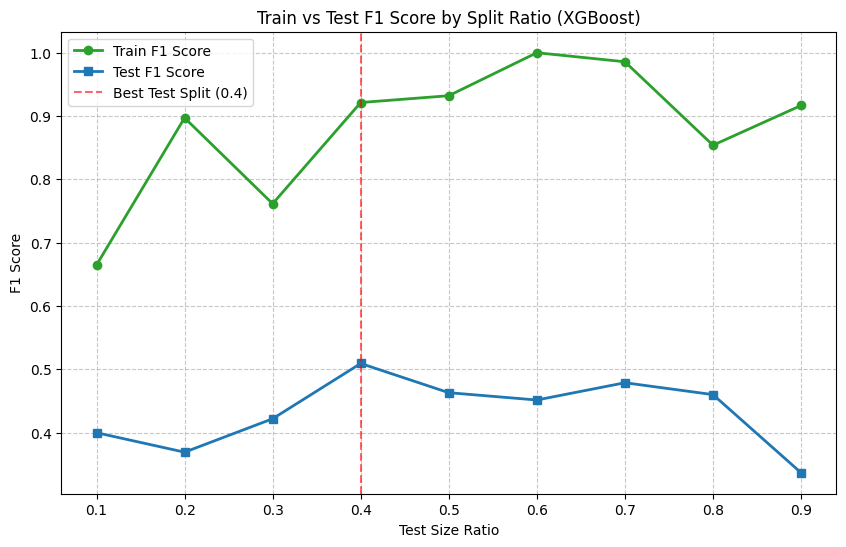

In [7]:
# 繪製 Train 與 Test 的 F1 Score 比較圖
plt.figure(figsize=(10, 6))

# 畫出 Train 和 Test 的線
plt.plot(split_ratios, train_f1_scores, marker='o', linestyle='-', color='#2ca02c', linewidth=2, label='Train F1 Score')
plt.plot(split_ratios, test_f1_scores, marker='s', linestyle='-', color='#1f77b4', linewidth=2, label='Test F1 Score')

# 標示最佳測試集比例
plt.axvline(x=best_sr, color='r', linestyle='--', alpha=0.6, label=f'Best Test Split ({best_sr})')

plt.title('Train vs Test F1 Score by Split Ratio (XGBoost)')
plt.xlabel('Test Size Ratio')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

- 發現：模型有嚴重的過擬合問題（F1 Score 在 0.66-1 的區間）。
- 下一步：採用「增加權重」、「固定切分比例（0.2）」以及「交叉驗證」來試著處理過擬合問題。

### 解決 over fitting 問題

In [8]:
# 1. 固定用 8:2 切分，保留 80% 資料給 AutoML
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. 更新 AutoML 的設定
settings = {
    "time_budget": 300,          # 增加時間
    "metric": "f1",              # F1 分數指標
    "estimator_list": ["xgboost"],
    "task": "classification",
    "log_file_name": "xgboost_cv_experiment.log",
    "seed": 42,
    "verbose": 0,

    # === 加入以下設定來對抗 Overfitting ===
    "eval_method": "cv",         # 強制使用 Cross-Validation 來評估參數好壞
    "n_splits": 5,               # 將訓練集切為 5 份進行交叉驗證
}

# 3. 重新訓練
automl = AutoML()
print(f"開始訓練 AutoML (限時 {settings['time_budget']} 秒)...")
automl.fit(X_train=X_train, y_train=y_train, sample_weight=weights, **settings)

# 4. 預測與評估
train_preds = automl.predict(X_train)
test_preds = automl.predict(X_test)

train_score = f1_score(y_train, train_preds)
test_score = f1_score(y_test, test_preds)
print("\n=== 訓練完成 ===")
print(f"Train F1 = {train_score:.4f}")
print(f"Test F1 = {test_score:.4f}")

# 看看 AutoML 最終選擇了哪些抗 Overfitting 的參數
print("\n最終使用的最佳超參數:")
print(automl.best_config)

開始訓練 AutoML (限時 300 秒)...

=== 訓練完成 ===
Train F1 = 0.6653
Test F1 = 0.5512

最終使用的最佳超參數:
{'n_estimators': 119, 'max_leaves': 88, 'min_child_weight': np.float64(34.85944376643502), 'learning_rate': np.float64(0.1803072035769704), 'subsample': np.float64(0.92712918241544), 'colsample_bylevel': np.float64(0.7209216629370009), 'colsample_bytree': np.float64(0.32585331900050796), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(1.8114866032828112)}


In [9]:
# 1. 貼上來自 ML_RF_LR.ipynb 的評估函數
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\n--- {model_name} 測試集表現 ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

# 2. 取得測試集的預測標籤與預測機率
test_preds = automl.predict(X_test)
# 取得機率值，通常 [:, 1] 代表「離職(Yes)」的機率
test_preds_proba = automl.predict_proba(X_test)[:, 1]

# 3. 呼叫函數，得到最終 XGBoost 的測試集表現
metrics_xgb = evaluate_model(y_test, test_preds, test_preds_proba, "AutoML XGBoost")


--- AutoML XGBoost 測試集表現 ---
Accuracy: 0.8061
Precision: 0.4375
Recall: 0.7447
F1-score: 0.5512
ROC AUC: 0.8075


## 混淆矩陣

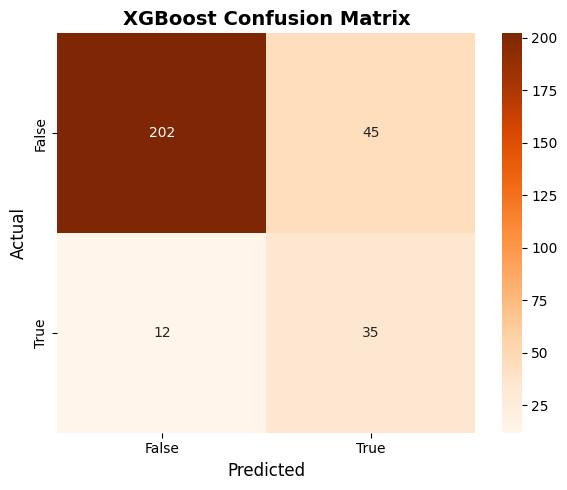

In [10]:
def plot_cm_xgb(y_true, y_pred):
    # 計算混淆矩陣
    cm_xgb = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))

    # 使用熱圖繪製 XGBoost 混淆矩陣 (改用不同的顏色 cmap='Oranges' 區別)
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['False', 'True'], yticklabels=['False', 'True'])

    ax.set_title('XGBoost Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

    plt.tight_layout()
    plt.show()

# 1. 使用最佳模型對測試集進行預測
test_preds = automl.predict(X_test)

# 2. 繪製混淆矩陣
plot_cm_xgb(y_test, test_preds)

## 特徵重要性圖

/tmp/ipykernel_1279/3569960329.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


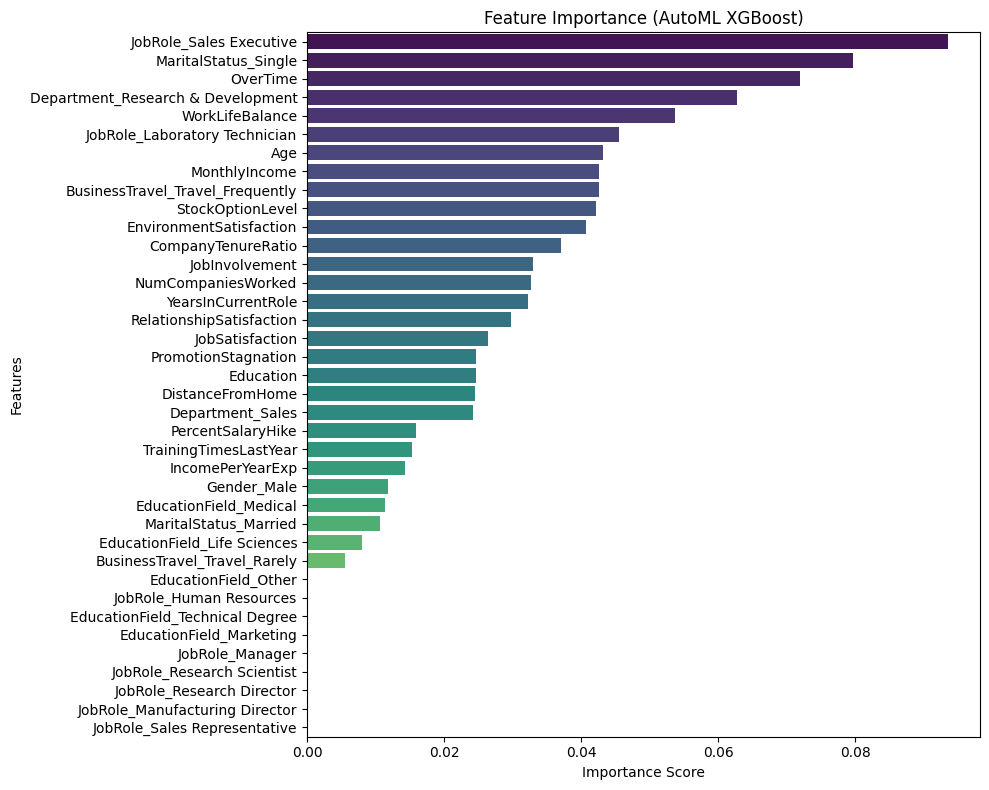

In [11]:
# 取得 AutoML 模型的特徵重要度與特徵名稱
importances = automl.feature_importances_
feature_names = automl.feature_names_in_

# 整理成 DataFrame 並由大到小排序
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 繪製前 20 個最重要的特徵
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance (AutoML XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 輸出模型

In [12]:
# 將訓練好的 automl 模型寫入檔案
# joblib.dump(automl, 'model_xgb.pkl')